Strategy # 1A: Simple Moving Average (Long only - Using 5-minute data)

We determine the 12-period simple moving average (referred to as 'SMA12') and compare it with the price at that time. We (subjectively) select 12 since SMA12 would be the average price over one hour.

There are two conditions which we check.

If the price is greater than the SMA12, we go long. We continue to stay invested until the square-off condition is satisfied.

When the price becomes less than the SMA12, we square off our long position.

Our trading rules can be stated as

Buy when price > SMA12; Square off when price <= SMA12

In [36]:
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import warnings
import yfinance as yf

warnings.filterwarnings('ignore')

# For high level interative plots
import plotly.express as px

# To show graphs in same notebook window
%matplotlib inline

In [37]:
end1 = datetime.date(2026, 6, 16)
start1 = end1 - pd.Timedelta(days=50)

In [38]:
df = yf.download("AAPL", start=start1, end=end1, interval="5m", auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [39]:
df

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Datetime,,,,,,
2026-04-27 13:30:00+00:00,266.149994,266.149994,267.880005,265.070007,266.089996,4317221
2026-04-27 13:35:00+00:00,267.199890,267.199890,267.250000,266.101990,266.179993,1185064
2026-04-27 13:40:00+00:00,267.484985,267.484985,267.739990,267.029999,267.170013,719882
2026-04-27 13:45:00+00:00,267.970001,267.970001,268.119995,267.309998,267.494995,745855
2026-04-27 13:50:00+00:00,267.910004,267.910004,268.239990,267.420013,267.979889,635578
...,...,...,...,...,...,...
2026-06-15 19:35:00+00:00,296.160004,296.160004,296.410004,295.870087,296.380005,377890
2026-06-15 19:40:00+00:00,296.320099,296.320099,296.394989,296.000000,296.149994,334037


In [40]:
df.shape

(2730, 6)

In [41]:
df.columns

MultiIndex([('Adj Close', 'AAPL'),
            (    'Close', 'AAPL'),
            (     'High', 'AAPL'),
            (      'Low', 'AAPL'),
            (     'Open', 'AAPL'),
            (   'Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [42]:
df.columns = df.columns.droplevel(1)
df.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [43]:
df1 = df.copy()
df1

Price,Adj Close,Close,High,Low,Open,Volume
Datetime,,,,,,
2026-04-27 13:30:00+00:00,266.149994,266.149994,267.880005,265.070007,266.089996,4317221
2026-04-27 13:35:00+00:00,267.199890,267.199890,267.250000,266.101990,266.179993,1185064
2026-04-27 13:40:00+00:00,267.484985,267.484985,267.739990,267.029999,267.170013,719882
2026-04-27 13:45:00+00:00,267.970001,267.970001,268.119995,267.309998,267.494995,745855
2026-04-27 13:50:00+00:00,267.910004,267.910004,268.239990,267.420013,267.979889,635578
...,...,...,...,...,...,...
2026-06-15 19:35:00+00:00,296.160004,296.160004,296.410004,295.870087,296.380005,377890
2026-06-15 19:40:00+00:00,296.320099,296.320099,296.394989,296.000000,296.149994,334037
2026-06-15 19:45:00+00:00,296.359985,296.359985,296.434998,296.154999,296.329987,492679


In [44]:
df1['cc_returns'] = df1['Close'].pct_change()
df1

Price,Adj Close,Close,High,Low,Open,Volume,cc_returns
Datetime,,,,,,,
2026-04-27 13:30:00+00:00,266.149994,266.149994,267.880005,265.070007,266.089996,4317221,NaN
2026-04-27 13:35:00+00:00,267.199890,267.199890,267.250000,266.101990,266.179993,1185064,0.003945
2026-04-27 13:40:00+00:00,267.484985,267.484985,267.739990,267.029999,267.170013,719882,0.001067
2026-04-27 13:45:00+00:00,267.970001,267.970001,268.119995,267.309998,267.494995,745855,0.001813
2026-04-27 13:50:00+00:00,267.910004,267.910004,268.239990,267.420013,267.979889,635578,-0.000224
...,...,...,...,...,...,...,...
2026-06-15 19:35:00+00:00,296.160004,296.160004,296.410004,295.870087,296.380005,377890,-0.000742
2026-06-15 19:40:00+00:00,296.320099,296.320099,296.394989,296.000000,296.149994,334037,0.000541
2026-06-15 19:45:00+00:00,296.359985,296.359985,296.434998,296.154999,296.329987,492679,0.000135


In [45]:
sma = 12
df1['sma'] = df1['Close'].rolling(window=sma).mean()
df1

Price,Adj Close,Close,High,Low,Open,Volume,cc_returns,sma
Datetime,,,,,,,,
2026-04-27 13:30:00+00:00,266.149994,266.149994,267.880005,265.070007,266.089996,4317221,NaN,NaN
2026-04-27 13:35:00+00:00,267.199890,267.199890,267.250000,266.101990,266.179993,1185064,0.003945,NaN
2026-04-27 13:40:00+00:00,267.484985,267.484985,267.739990,267.029999,267.170013,719882,0.001067,NaN
2026-04-27 13:45:00+00:00,267.970001,267.970001,268.119995,267.309998,267.494995,745855,0.001813,NaN
2026-04-27 13:50:00+00:00,267.910004,267.910004,268.239990,267.420013,267.979889,635578,-0.000224,NaN
...,...,...,...,...,...,...,...,...
2026-06-15 19:35:00+00:00,296.160004,296.160004,296.410004,295.870087,296.380005,377890,-0.000742,296.274139
2026-06-15 19:40:00+00:00,296.320099,296.320099,296.394989,296.000000,296.149994,334037,0.000541,296.283315
2026-06-15 19:45:00+00:00,296.359985,296.359985,296.434998,296.154999,296.329987,492679,0.000135,296.295481


In [46]:
df1['position'] = np.where((df1['Close'] > df1['sma']),1,0)
df1

Price,Adj Close,Close,High,Low,Open,Volume,cc_returns,sma,position
Datetime,,,,,,,,,
2026-04-27 13:30:00+00:00,266.149994,266.149994,267.880005,265.070007,266.089996,4317221,NaN,NaN,0
2026-04-27 13:35:00+00:00,267.199890,267.199890,267.250000,266.101990,266.179993,1185064,0.003945,NaN,0
2026-04-27 13:40:00+00:00,267.484985,267.484985,267.739990,267.029999,267.170013,719882,0.001067,NaN,0
2026-04-27 13:45:00+00:00,267.970001,267.970001,268.119995,267.309998,267.494995,745855,0.001813,NaN,0
2026-04-27 13:50:00+00:00,267.910004,267.910004,268.239990,267.420013,267.979889,635578,-0.000224,NaN,0
...,...,...,...,...,...,...,...,...,...
2026-06-15 19:35:00+00:00,296.160004,296.160004,296.410004,295.870087,296.380005,377890,-0.000742,296.274139,0
2026-06-15 19:40:00+00:00,296.320099,296.320099,296.394989,296.000000,296.149994,334037,0.000541,296.283315,1
2026-06-15 19:45:00+00:00,296.359985,296.359985,296.434998,296.154999,296.329987,492679,0.000135,296.295481,1


In [47]:
df1['position'] = df1['position'].shift(1)

In [48]:
df1['strategy_returns'] = df1['cc_returns'] * df1['position']
df1['strategy_returns'] = 1 + df1['strategy_returns']
df1['cc_returns'] = 1 + df1['cc_returns']
df1

Price,Adj Close,Close,High,Low,Open,Volume,cc_returns,sma,position,strategy_returns
Datetime,,,,,,,,,,
2026-04-27 13:30:00+00:00,266.149994,266.149994,267.880005,265.070007,266.089996,4317221,NaN,NaN,NaN,NaN
2026-04-27 13:35:00+00:00,267.199890,267.199890,267.250000,266.101990,266.179993,1185064,1.003945,NaN,0.0,1.000000
2026-04-27 13:40:00+00:00,267.484985,267.484985,267.739990,267.029999,267.170013,719882,1.001067,NaN,0.0,1.000000
2026-04-27 13:45:00+00:00,267.970001,267.970001,268.119995,267.309998,267.494995,745855,1.001813,NaN,0.0,1.000000
2026-04-27 13:50:00+00:00,267.910004,267.910004,268.239990,267.420013,267.979889,635578,0.999776,NaN,0.0,1.000000
...,...,...,...,...,...,...,...,...,...,...
2026-06-15 19:35:00+00:00,296.160004,296.160004,296.410004,295.870087,296.380005,377890,0.999258,296.274139,1.0,0.999258
2026-06-15 19:40:00+00:00,296.320099,296.320099,296.394989,296.000000,296.149994,334037,1.000541,296.283315,0.0,1.000000
2026-06-15 19:45:00+00:00,296.359985,296.359985,296.434998,296.154999,296.329987,492679,1.000135,296.295481,1.0,1.000135


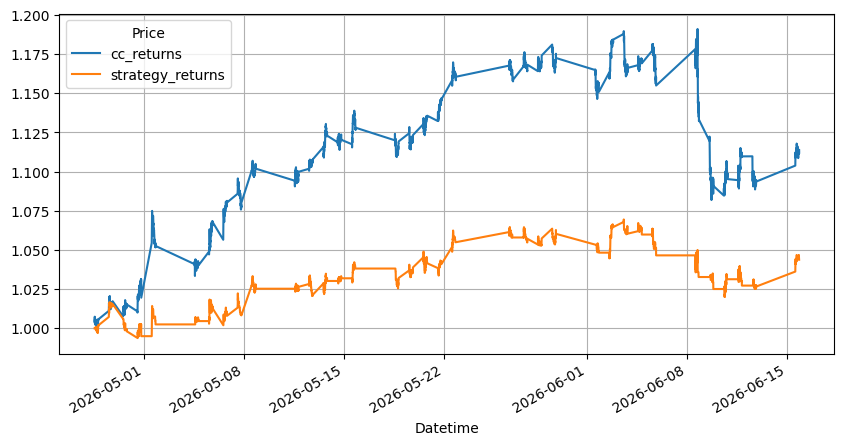

In [49]:
df1[['cc_returns', 'strategy_returns']].cumprod().plot(grid=True, figsize=(10, 5));
plt.show()

In [50]:
print('Buy and hold returns : ', np.round(df1['cc_returns'].cumprod()[-1]-1, 2))
print('Strategy returns : ', np.round(df1['strategy_returns'].cumprod()[-1]-1, 2))

Buy and hold returns :  0.11
Strategy returns :  0.04


Strategy # 1B: Exponential Moving Average (Long only - Using 5-minute data)

We determine the 12-period exponential moving average (referred to as 'EMA12') and compare it with the price at that time. We (subjectively) select 12 since SMA12 would be the average price over one hour.

There are two conditions which we check.

If the price is greater than the EMA12, we go long. We continue to stay invested until the square-off condition is satisfied.

When the price becomes less than the EMA12, we square off our long position.

Our trading rules can be stated as

Buy when price > EMA12; Square off when price <= EMA12

In [51]:
df2 = df.copy()
df2

Price,Adj Close,Close,High,Low,Open,Volume
Datetime,,,,,,
2026-04-27 13:30:00+00:00,266.149994,266.149994,267.880005,265.070007,266.089996,4317221
2026-04-27 13:35:00+00:00,267.199890,267.199890,267.250000,266.101990,266.179993,1185064
2026-04-27 13:40:00+00:00,267.484985,267.484985,267.739990,267.029999,267.170013,719882
2026-04-27 13:45:00+00:00,267.970001,267.970001,268.119995,267.309998,267.494995,745855
2026-04-27 13:50:00+00:00,267.910004,267.910004,268.239990,267.420013,267.979889,635578
...,...,...,...,...,...,...
2026-06-15 19:35:00+00:00,296.160004,296.160004,296.410004,295.870087,296.380005,377890
2026-06-15 19:40:00+00:00,296.320099,296.320099,296.394989,296.000000,296.149994,334037
2026-06-15 19:45:00+00:00,296.359985,296.359985,296.434998,296.154999,296.329987,492679


In [52]:
df2['cc_returns'] = df2['Close'].pct_change()
ema = 12
df2['ema'] = df2['Close'].ewm(span=ema).mean()
df2

Price,Adj Close,Close,High,Low,Open,Volume,cc_returns,ema
Datetime,,,,,,,,
2026-04-27 13:30:00+00:00,266.149994,266.149994,267.880005,265.070007,266.089996,4317221,NaN,266.149994
2026-04-27 13:35:00+00:00,267.199890,267.199890,267.250000,266.101990,266.179993,1185064,0.003945,266.718688
2026-04-27 13:40:00+00:00,267.484985,267.484985,267.739990,267.029999,267.170013,719882,0.001067,267.017774
2026-04-27 13:45:00+00:00,267.970001,267.970001,268.119995,267.309998,267.494995,745855,0.001813,267.318355
2026-04-27 13:50:00+00:00,267.910004,267.910004,268.239990,267.420013,267.979889,635578,-0.000224,267.479104
...,...,...,...,...,...,...,...,...
2026-06-15 19:35:00+00:00,296.160004,296.160004,296.410004,295.870087,296.380005,377890,-0.000742,296.203942
2026-06-15 19:40:00+00:00,296.320099,296.320099,296.394989,296.000000,296.149994,334037,0.000541,296.221812
2026-06-15 19:45:00+00:00,296.359985,296.359985,296.434998,296.154999,296.329987,492679,0.000135,296.243070


In [53]:
df2['position'] = np.where((df2['Close'] > df2['ema']),1,0)
df2['position'] = df2['position'].shift(1)

In [54]:
df2['strategy_returns'] = df2['cc_returns'] * df2['position']
df2['strategy_returns'] = 1 + df2['strategy_returns']
df2['cc_returns'] = 1 + df2['cc_returns']

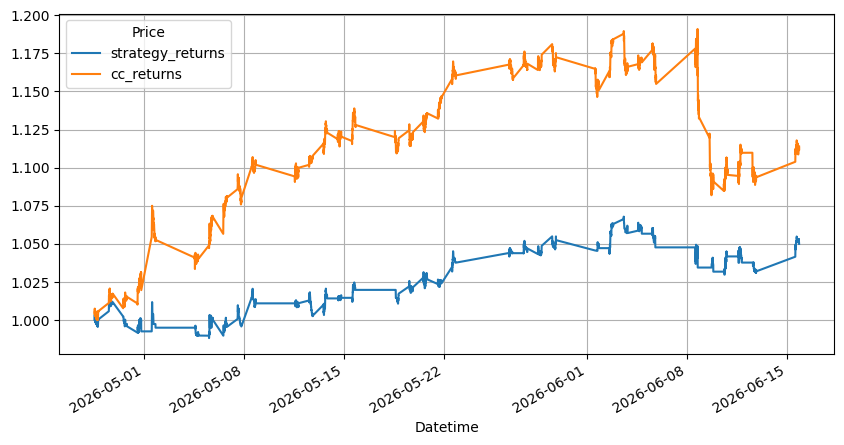

In [55]:
df2[['strategy_returns','cc_returns']].cumprod().plot(grid=True, figsize=(10, 5));
plt.show()

In [56]:
print('Buy and hold returns : ', np.round(df2['cc_returns'].cumprod()[-1]-1, 2))
print('Strategy returns : ', np.round(df2['strategy_returns'].cumprod()[-1]-1, 2))

Buy and hold returns :  0.11
Strategy returns :  0.05
